# Examples of Neural Reparameterization vs Classical Solvers vs Hybrid KAN
This notebook directly ports the exact testing sequence from the `neural-structural-optimization` package. 
It evaluates each test sequentially across 5 methods at the same time: `MMA`, `OC`, `Pixel-LBFGS`, `CNN`, AND `KAN`.


In [4]:
import os
import sys
from pathlib import Path

# Windows DLL fix for torch inside notebook kernels
if sys.platform == "win32":
    import importlib.util
    _spec = importlib.util.find_spec("torch")
    if _spec:
        _torch_lib = Path(_spec.origin).parent / "lib"
        if _torch_lib.is_dir():
            try:
                os.add_dll_directory(str(_torch_lib))
            except Exception:
                pass

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from PIL import Image

# Import local standalone modules
from neural_structural_optimization import problems, topo_api
import models as pt

print(f"PyTorch Version: {torch.__version__}")


PyTorch Version: 2.11.0+cpu


In [5]:
def train_all(problem, max_iterations, cnn_kwargs=None, kan_kwargs=None, baseline_kan_kwargs=None):
    """Run MMA, OC, Pixel, CNN, KAN (Hybrid), and Baseline KAN for the given problem."""
    args = topo_api.specified_task(problem)
    if cnn_kwargs is None:
        cnn_kwargs = {}
    
    if kan_kwargs is None:
        kan_kwargs = {}
        # Attempt to copy spatial resizes from CNN if available
        if "resizes" in cnn_kwargs:
            kan_kwargs["resizes"] = cnn_kwargs["resizes"]
            
    if baseline_kan_kwargs is None:
        baseline_kan_kwargs = {}

    print("Running MMA...")
    try:
        import nlopt
        ds_mma = pt.method_of_moving_asymptotes(pt.PixelModel(args=args), max_iterations)
    except ImportError:
        print("nlopt not found. MMA unavailable.")
        ds_mma = None
        
    print("Running L-BFGS (Pixel)...")
    ds_pix = pt.train_lbfgs(pt.PixelModel(args=args), max_iterations)

    print("Running OC...")
    ds_oc = pt.optimality_criteria(pt.PixelModel(args=args), max_iterations)

    print("Running L-BFGS (CNN)...")
    ds_cnn = pt.train_lbfgs(pt.CNNModel(args=args, **cnn_kwargs), max_iterations)

    print("Running L-BFGS (Hybrid KAN)...")
    ds_kan = pt.train_lbfgs(pt.KANModel(args=args, **kan_kwargs), max_iterations)
    
    print("Running L-BFGS (Baseline KAN)...")
    ds_baseline_kan = pt.train_lbfgs(pt.CoordKANModel(args=args, **baseline_kan_kwargs), max_iterations)

    # Collect datasets dynamically (avoiding nulls if MMA is missing)
    ds_list = []
    labels = []
    
    if ds_mma is not None:
        ds_list.append(ds_mma)
        labels.append('mma')
    ds_list.extend([ds_oc, ds_pix, ds_cnn, ds_kan, ds_baseline_kan])
    labels.extend(['oc', 'pixel-lbfgs', 'cnn-lbfgs', 'hybrid-kan-lbfgs', 'baseline-kan-lbfgs'])
        
    dims = pd.Index(labels, name='model')
    return xr.concat(ds_list, dim=dims)

def summarize_case(ds_case, case_name=""):
    import pandas as pd
    import numpy as np
    from IPython.display import display
    rows = []
    for model_name in ds_case.coords["model"].values:
        losses = ds_case.loss.sel(model=model_name).values
        best_step = int(np.nanargmin(losses))
        rows.append({
            "Case": case_name,
            "Model": str(model_name),
            "Best Compliance (Loss)": float(losses[best_step]),
            "Step Achieved": best_step,
        })
    df = pd.DataFrame(rows).sort_values("Best Compliance (Loss)").reset_index(drop=True)
    display(df)
    return df


## MBB Beam (Figure 2 from paper)
Note that we tweaked the CNN model slightly from the original version of the paper, which results in a slightly worse design in this particular case.


In [30]:
problem = problems.mbb_beam(height=20, width=60)
max_iterations = 200

# can't upscale by exactly 8x for a 60x20 design region, so upscale by only 4x instead
ds_mbb20 = train_all(problem, max_iterations, cnn_kwargs=dict(resizes=(1, 1, 2, 2, 1)))


Running MMA...
Running L-BFGS (Pixel)...


c:\Users\yzkrm\Desktop\MIE Research\.venv\Lib\site-packages\autograd\tracer.py:54: RuntimeWarning: overflow encountered in cosh
  return f_raw(*args, **kwargs)
c:\Users\yzkrm\Desktop\MIE Research\.venv\Lib\site-packages\autograd\numpy\numpy_vjps.py:175: RuntimeWarning: overflow encountered in square
  defvjp(anp.tanh, lambda ans, x: lambda g: g / anp.cosh(x) ** 2)


Running OC...
Running L-BFGS (CNN)...
Running L-BFGS (Hybrid KAN)...
Running L-BFGS (Baseline KAN)...


In [34]:
summarize_case(ds_mbb20, "MBB Beam (60x20)")


,Case,Model,Best Compliance (Loss),Step Achieved
0,MBB Beam (60x20),mma,218.446638,137
1,MBB Beam (60x20),cnn-lbfgs,219.250879,200
2,MBB Beam (60x20),oc,219.715594,200
3,MBB Beam (60x20),hybrid-kan-lbfgs,225.730559,200
4,MBB Beam (60x20),pixel-lbfgs,237.849727,200
5,MBB Beam (60x20),baseline-kan-lbfgs,583.300087,200


,Case,Model,Best Compliance (Loss),Step Achieved
0,MBB Beam (60x20),mma,218.446638,137
1,MBB Beam (60x20),cnn-lbfgs,219.250879,200
2,MBB Beam (60x20),oc,219.715594,200
3,MBB Beam (60x20),hybrid-kan-lbfgs,225.730559,200
4,MBB Beam (60x20),pixel-lbfgs,237.849727,200
5,MBB Beam (60x20),baseline-kan-lbfgs,583.300087,200


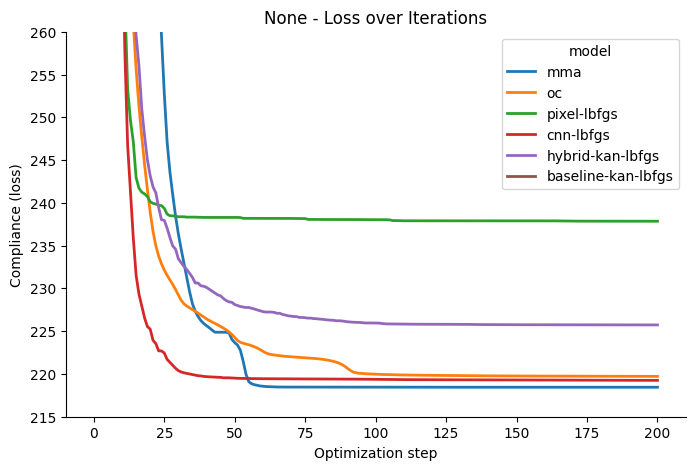

In [31]:
# Plot convergence profiles
ds_mbb20.loss.transpose().to_pandas().cummin().loc[:200].plot(linewidth=2, figsize=(8,5))
plt.ylim(215, 260)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
sns.despine()
plt.title(f"{problem.name} - Loss over Iterations")
plt.show()


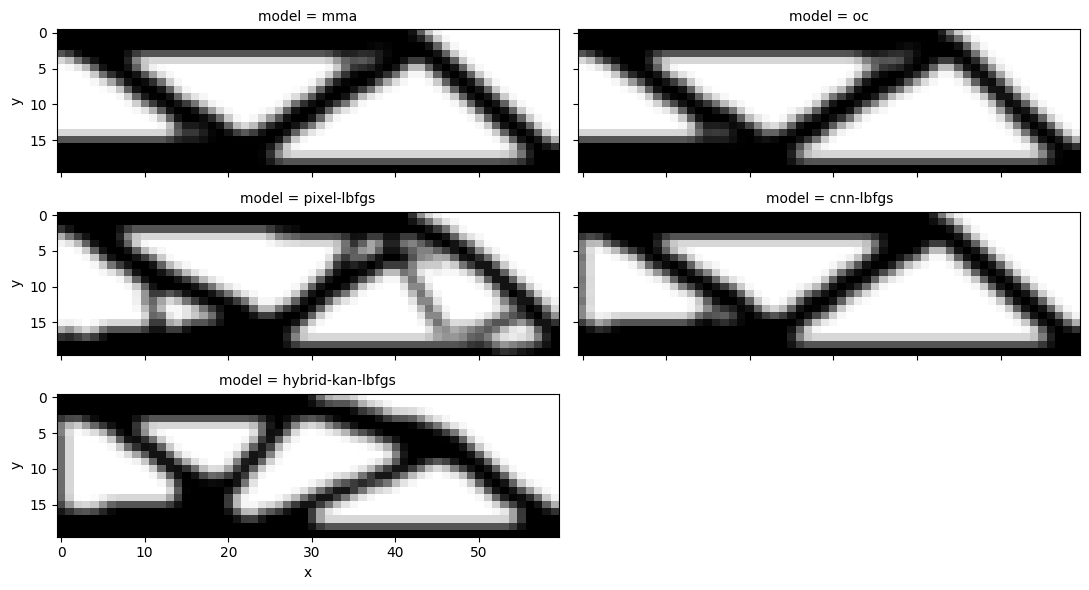

In [12]:
# Display designs
ds_mbb20.design.sel(step=200).plot.imshow(
    col='model', x='x', y='y', size=2, aspect=2.5, col_wrap=2,
    yincrease=False, add_colorbar=False, cmap='Greys')
plt.show()


## MBB beam with a larger grid


In [7]:
problem = problems.PROBLEMS_BY_NAME['mbb_beam_192x64_0.4']
max_iterations = 100
ds_mbb192 = train_all(problem, max_iterations, cnn_kwargs=dict(resizes=(1, 2, 2, 2, 1)))


Running MMA...
Running L-BFGS (Pixel)...


c:\Users\yzkrm\Desktop\MIE Research\.venv\Lib\site-packages\autograd\numpy\numpy_vjps.py:175: RuntimeWarning: overflow encountered in square
  defvjp(anp.tanh, lambda ans, x: lambda g: g / anp.cosh(x) ** 2)
c:\Users\yzkrm\Desktop\MIE Research\.venv\Lib\site-packages\autograd\tracer.py:54: RuntimeWarning: overflow encountered in cosh
  return f_raw(*args, **kwargs)


Running OC...
Running L-BFGS (CNN)...
Running L-BFGS (KAN)...


C:\Users\yzkrm\AppData\Local\Temp\ipykernel_13644\3793306563.py:50: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'step' ('step',) The recommendation is to set join explicitly for this case.
  return xr.concat(ds_list, dim=dims)


In [ ]:
summarize_case(ds_mbb192, "MBB Beam (192x64)")


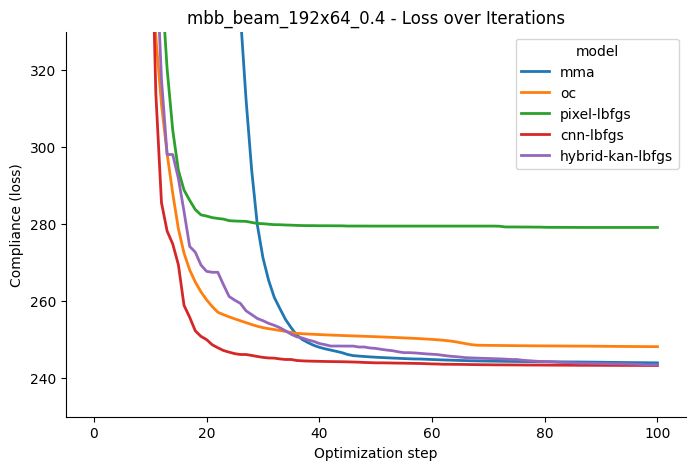

In [13]:
ds_mbb192.loss.transpose().to_pandas().cummin().loc[:100].plot(linewidth=2, figsize=(8,5))
plt.ylim(230, 330)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
sns.despine()
plt.title(f"{problem.name} - Loss over Iterations")
plt.show()


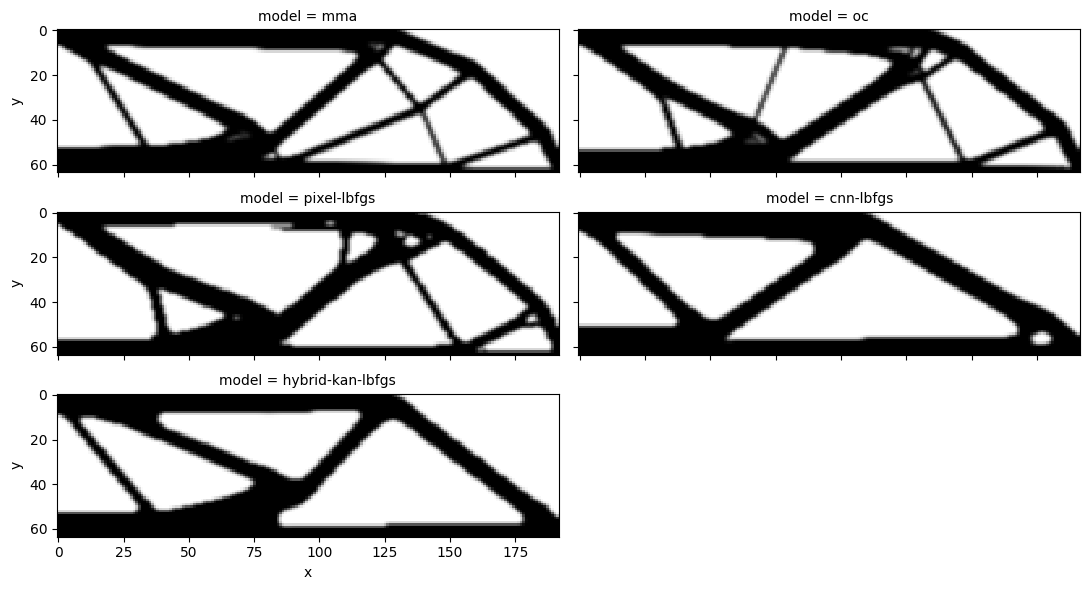

In [37]:
# the pixel-lbfgs does not run for the full 100 steps (it terminates
# early due to reaching a local minima), so use fill() to forward fill
# to the last valid design.
ds_mbb192.design.ffill('step').sel(step=100).plot.imshow(
    col='model', x='x', y='y', size=2, aspect=2.5, col_wrap=2,
    yincrease=False, add_colorbar=False, cmap='Greys')
plt.suptitle(problem.name, y=1.02)
plt.show()


## Multistory building


In [ ]:
problem = problems.PROBLEMS_BY_NAME['multistory_building_64x128_0.4']
max_iterations = 100
ds_bldg = train_all(problem, max_iterations, cnn_kwargs=dict(resizes=(1, 2, 2, 2, 1)))


In [ ]:
summarize_case(ds_bldg, "Multistory Building (128x64)")


In [ ]:
ds_bldg.loss.transpose().to_pandas().cummin().loc[:100].plot(linewidth=2, figsize=(8,5))
plt.ylim(40, 100)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
sns.despine()
plt.title(f"{problem.name} - Loss over Iterations")
plt.show()


In [ ]:
# Display designs
ds_bldg.design.ffill('step').sel(step=100).plot.imshow(
    col='model', x='x', y='y', size=3, aspect=0.5, col_wrap=3,
    yincrease=False, add_colorbar=False, cmap='Greys')
plt.suptitle(problem.name, y=1.02)
plt.show()


## Thin support bridge


In [38]:
# we really need more iterations to see the neural methods dominate over early checkerboarding
problem = problems.PROBLEMS_BY_NAME['thin_support_bridge_128x128_0.2']
max_iterations = 150
ds_bridge = train_all(problem, max_iterations, cnn_kwargs=dict(resizes=(1, 2, 2, 2, 1)))


Running MMA...


c:\Users\yzkrm\Desktop\MIE Research\kan-cnn-comparison\neural_structural_optimization\autograd_lib.py:102: RuntimeWarning: divide by zero encountered in divide
  weights = 1 / raw_filters.sum(axis=0).squeeze()


Running L-BFGS (Pixel)...
Running OC...
Running L-BFGS (CNN)...
Running L-BFGS (Hybrid KAN)...
Running L-BFGS (Baseline KAN)...


C:\Users\yzkrm\AppData\Local\Temp\ipykernel_13644\2935168736.py:60: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'step' ('step',) The recommendation is to set join explicitly for this case.
  return xr.concat(ds_list, dim=dims)


In [39]:
summarize_case(ds_bridge, "Thin Support Bridge (128x128)")


,Case,Model,Best Compliance (Loss),Step Achieved
0,Thin Support Bridge (128x128),mma,80.935272,149
1,Thin Support Bridge (128x128),cnn-lbfgs,82.726593,150
2,Thin Support Bridge (128x128),oc,84.454790,150
3,Thin Support Bridge (128x128),hybrid-kan-lbfgs,92.116864,150
4,Thin Support Bridge (128x128),pixel-lbfgs,105.681194,151
5,Thin Support Bridge (128x128),baseline-kan-lbfgs,895.079565,150


,Case,Model,Best Compliance (Loss),Step Achieved
0,Thin Support Bridge (128x128),mma,80.935272,149
1,Thin Support Bridge (128x128),cnn-lbfgs,82.726593,150
2,Thin Support Bridge (128x128),oc,84.454790,150
3,Thin Support Bridge (128x128),hybrid-kan-lbfgs,92.116864,150
4,Thin Support Bridge (128x128),pixel-lbfgs,105.681194,151
5,Thin Support Bridge (128x128),baseline-kan-lbfgs,895.079565,150


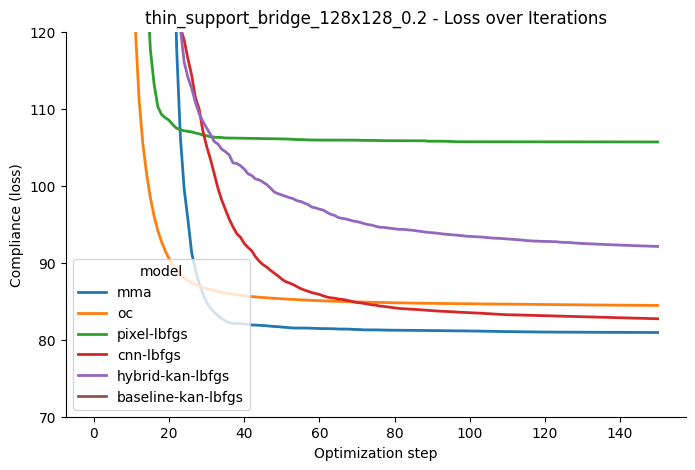

In [40]:
ds_bridge.loss.transpose().to_pandas().cummin().loc[:150].plot(linewidth=2, figsize=(8,5))
plt.ylim(70, 120)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
sns.despine()
plt.title(f"{problem.name} - Loss over Iterations")
plt.show()


In [ ]:
(xr.concat([ds_bridge.design, ds_bridge.design.sel(x=slice(None, None, -1))] * 2, dim='x')
 .ffill('step').sel(step=150)
 .plot.imshow(
    col='model', x='x', y='y', size=3, aspect=2, col_wrap=2,
    yincrease=False, add_colorbar=False, cmap='Greys'))
plt.suptitle(problem.name, y=1.02)
plt.show()
